### Policy Gradients and Epsilon Greedy with Decaying Epsilon

### Install Dependencies

In [13]:
pip install gym torch tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gym
from gym import spaces
import matplotlib.pyplot as plt
from tqdm import tqdm

In [15]:
class MultiArmedBanditEnv(gym.Env):
    def __init__(self, n_arms, means, stds):
        super(MultiArmedBanditEnv, self).__init__()
        self.n_arms = n_arms
        self.means = means
        self.stds = stds
        self.action_space = spaces.Discrete(self.n_arms)
        self.observation_space = spaces.Discrete(1)

    def reset(self):
        return 0

    def step(self, action):
        reward = np.random.normal(self.means[action], self.stds[action])
        return 0, reward, True, {}

### Epsilon-Greedy Agent

In [16]:
class EpsilonGreedyAgent:
    def __init__(self, n_arms, epsilon=1.0, min_epsilon=0.01, decay_rate=0.99, device='cuda'):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.decay_rate = decay_rate
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.Q = torch.zeros(n_arms, device=self.device)
        self.N = torch.zeros(n_arms, device=self.device)

    def select_action(self, step):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.decay_rate)
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)
        return torch.argmax(self.Q).item()

    def update(self, action, reward):
        self.N[action] += 1
        alpha = 1.0 / self.N[action]
        self.Q[action] += alpha * (reward - self.Q[action])

### Training Loop

In [17]:
def train(env, agent, steps=500):
    rewards = []
    optimal_actions = []
    best_arm = np.argmax(env.means)

    for step in range(steps):
        action = agent.select_action(step)
        _, reward, _, _ = env.step(action)
        agent.update(action, reward)
        rewards.append(reward)
        optimal_actions.append(1 if action == best_arm else 0)

    return rewards, optimal_actions

### Exploration Efficiency

In [18]:
def compute_exploration_efficiency(optimal_actions, window=50, threshold=0.95):
    """
    optimal_actions: list of 0/1s indicating if optimal arm was chosen
    window: number of steps for moving average
    threshold: minimum optimal rate for convergence
    """
    optimal_actions = np.array(optimal_actions)
    for t in range(window, len(optimal_actions)):
        if np.mean(optimal_actions[t - window:t]) >= threshold:
            return t
    return len(optimal_actions)

### Epsilon-Greedy Main

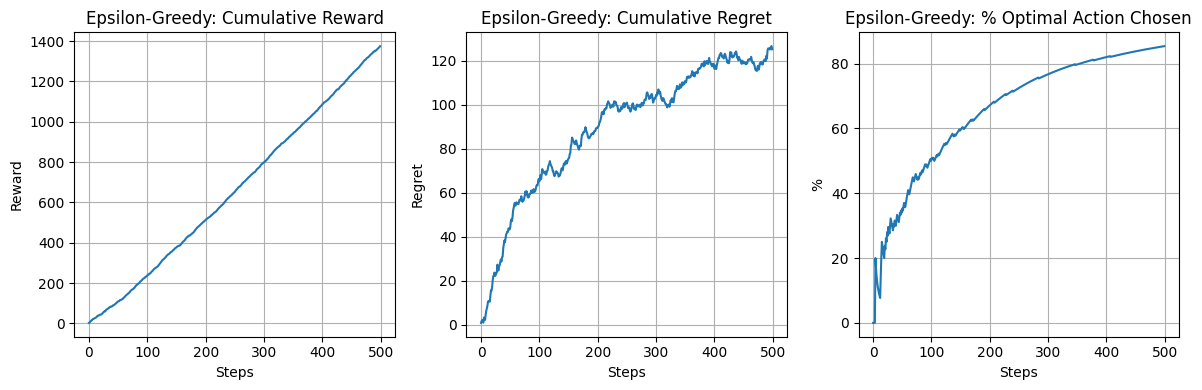

Epsilon-Greedy Exploration Efficiency: 223 steps


In [19]:
if __name__ == "__main__":
    # Setup
    n_arms = 5
    means = [1.0, 1.5, 2.0, 2.5, 3.0]
    stds = [1.0] * n_arms
    env = MultiArmedBanditEnv(n_arms, means, stds)
    agent = EpsilonGreedyAgent(n_arms, epsilon=1.0, min_epsilon=0.01, decay_rate=0.99)

    # Train
    rewards, optimal_actions = train(env, agent, steps=500)

    # Evaluate
    cumulative_reward = np.cumsum(rewards)
    cumulative_regret = np.cumsum(np.max(means) - np.array(rewards))
    optimal_action_percent = np.cumsum(optimal_actions) / np.arange(1, len(optimal_actions)+1) * 100
    efficiency = compute_exploration_efficiency(optimal_actions)

    # Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(cumulative_reward)
    plt.title("Epsilon-Greedy: Cumulative Reward")
    plt.xlabel("Steps")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.subplot(1, 3, 2)
    plt.plot(cumulative_regret)
    plt.title("Epsilon-Greedy: Cumulative Regret")
    plt.xlabel("Steps")
    plt.ylabel("Regret")
    plt.grid(True)
    plt.subplot(1, 3, 3)
    plt.plot(optimal_action_percent)
    plt.title("Epsilon-Greedy: % Optimal Action Chosen")
    plt.xlabel("Steps")
    plt.ylabel("%")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Epsilon-Greedy Exploration Efficiency: {efficiency} steps")

### Tuning Function

In [22]:
def tune_agent(env_class, agent_class, agent_params, steps=500, trials=50):
    all_regret = []
    all_optimal = []
    all_efficiency = []

    print(f"Tuning {agent_class.__name__}...")
    for _ in tqdm(range(trials), desc="Trials"):
        env = env_class()
        agent = agent_class(**agent_params)
        rewards, optimal_actions = train(env, agent, steps=steps)
        regret = np.sum(np.max(env.means) - np.array(rewards))
        optimal_rate = np.mean(optimal_actions) * 100
        efficiency = compute_exploration_efficiency(optimal_actions)
        all_regret.append(regret)
        all_optimal.append(optimal_rate)
        all_efficiency.append(efficiency)

    print("\nTuning Summary:")
    print(f"Average Cumulative Regret: {np.mean(all_regret):.2f}")
    print(f"Average % Optimal Actions: {np.mean(all_optimal):.2f}%")
    print(f"Average Exploration Efficiency: {np.mean(all_efficiency):.0f} steps")
    return np.mean(all_regret), np.mean(all_optimal), np.mean(all_efficiency)

### Environment Factory
- Creates the environment with specified parameters

In [23]:
def make_env():
    return MultiArmedBanditEnv(
        n_arms=5,
        means=[1.0, 1.5, 2.0, 2.5, 3.0],
        stds=[1.0]*5
    )

### Tuning Epsilon-Greedy

In [24]:
# Tune Epsilon-Greedy with different decay rates
decay_rates = [0.95, 0.99, 0.999]
results_eg = []
for dr in decay_rates:
    print(f"\nTesting Epsilon-Greedy with decay_rate={dr}")
    params = {"n_arms": 5, "epsilon": 1.0, "min_epsilon": 0.01, "decay_rate": dr}
    regret, optimal, efficiency = tune_agent(make_env, EpsilonGreedyAgent, params)
    results_eg.append((dr, regret, optimal, efficiency))


Testing Epsilon-Greedy with decay_rate=0.95
Tuning EpsilonGreedyAgent...


Trials: 100%|██████████| 50/50 [00:01<00:00, 25.14it/s]



Tuning Summary:
Average Cumulative Regret: 66.10
Average % Optimal Actions: 81.58%
Average Exploration Efficiency: 146 steps

Testing Epsilon-Greedy with decay_rate=0.99
Tuning EpsilonGreedyAgent...


Trials: 100%|██████████| 50/50 [00:02<00:00, 17.08it/s]



Tuning Summary:
Average Cumulative Regret: 95.00
Average % Optimal Actions: 83.09%
Average Exploration Efficiency: 260 steps

Testing Epsilon-Greedy with decay_rate=0.999
Tuning EpsilonGreedyAgent...


Trials: 100%|██████████| 50/50 [00:02<00:00, 18.68it/s]


Tuning Summary:
Average Cumulative Regret: 391.45
Average % Optimal Actions: 37.02%
Average Exploration Efficiency: 500 steps


## Epsilon-Greedy with Decaying Epsilon — Tuning Summary

| Metric                         | Value          |
|--------------------------------|----------------|
| **Average Cumulative Regret**  | 391.45         |
| **Average % Optimal Actions**  | 37.02%         |
| **Exploration Efficiency**     | 500 steps      |

---

### Interpretation:
- The agent fails to converge to the optimal arm within the 500-step limit, with an average exploration efficiency of 500 steps.
- It selects the best arm approximately 37% of the time, indicating significant exploration or convergence to suboptimal arms.
- The cumulative regret of 391.45 suggests poor performance, with room for improvement by tuning the decay rate or exploring alternative algorithms such as UCB or Thompson Sampling.

### LLM Propmts
- First: how to do Epsilon Greedy with Decaying Epsilon
in given Bandit enviroment
- Last: write me summary about tunning